# Variant Labeling Analysis
This notebook analyzes samples after variant labeling, including label distribution, sequence frequency distribution, and edit distance from wildtype sequences.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from Levenshtein import distance as levenshtein_distance

# Set plotting style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Explore Data
Load the CSV file containing variant data with labels. The dataset includes amino acid sequences,
their occurrence counts in different sample types (library, negative, positive 1x, positive 3x),
and variant labels (for classification: 0=negative, 1=positive 1x, 2=positive 3x).

In [2]:
# Load the CSV file containing labeled variants
# Load from the variant_labeling directory where labels already exist
df = pd.read_csv('../data/P3408_LUCA-TCRA3/variant_labeling/KH159.variant_labeling.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (171054, 23)

Column names:
['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'count_pos1x', 'freq_pos1x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos1x_vs_neg', 'enrich_pos3x_vs_lib', 'enrich_pos1x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos1x_vs_neg_status', 'pos3x_vs_lib_status', 'pos1x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificity']

First few rows:


,aa_seq,count_lib,freq_lib,count_neg,freq_neg,count_pos3x,freq_pos3x,count_pos1x,freq_pos1x,peptide,...,enrich_pos1x_vs_lib,deplete_neg_lib,pos3x_vs_neg_status,pos1x_vs_neg_status,pos3x_vs_lib_status,pos1x_vs_lib_status,pos_vs_neg_status,pos_vs_lib_status,neg_vs_lib_status,specificity
0,AGGANAADELF,89.0,1.364689e-05,132.0,1.927705e-05,0.0,0.0,0.0,0.0,KH159,...,0.000073,1.412530,Depleted,Depleted,Depleted,Depleted,Depleted,Depleted,NoChange,2
1,AGGANAADELY,2.0,3.066717e-07,4.0,5.841530e-07,0.0,0.0,0.0,0.0,KH159,...,0.003250,1.901875,Depleted,Depleted,Depleted,Depleted,Depleted,Depleted,NoChange,2
2,AGGANAADEQF,1.0,1.533358e-07,1.0,1.460383e-07,0.0,0.0,0.0,0.0,KH159,...,0.006479,0.952716,Depleted,Depleted,Depleted,Depleted,Depleted,Depleted,NoChange,2
3,AGGANAADEQY,30.0,4.600075e-06,69.0,1.007664e-05,0.0,0.0,0.0,0.0,KH159,...,0.000217,2.190279,Depleted,Depleted,Depleted,Depleted,Depleted,Depleted,Enriched,0
4,AGGANAADGLF,0.0,0.000000e+00,5.0,7.301913e-07,0.0,0.0,0.0,0.0,KH159,...,1.000000,731.191262,Depleted,Depleted,NoChange,NoChange,Depleted,NoChange,Enriched,0



Missing values:
aa_seq                 0
count_lib              0
freq_lib               0
count_neg              0
freq_neg               0
count_pos3x            0
freq_pos3x             0
count_pos1x            0
freq_pos1x             0
peptide                0
enrich_pos3x_vs_neg    0
enrich_pos1x_vs_neg    0
enrich_pos3x_vs_lib    0
enrich_pos1x_vs_lib    0
deplete_neg_lib        0
pos3x_vs_neg_status    0
pos1x_vs_neg_status    0
pos3x_vs_lib_status    0
pos1x_vs_lib_status    0
pos_vs_neg_status      0
pos_vs_lib_status      0
neg_vs_lib_status      0
specificity            0
dtype: int64


In [3]:
# Use the existing 'specificity' column as the label
# Labels are already defined in the data:
# - 0 = non-specific
# - 1 = specific
# - 2 = unclear

# Rename the specificity column to label for consistency with downstream processing
df['label'] = df['specificity'].astype(int)

# Display label distribution
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())
print(f"\nPercentage distribution:")
print((df['label'].value_counts(normalize=True).sort_index() * 100).round(2))


Label distribution:
label
0     48170
1      2035
2    120849
Name: count, dtype: int64

Percentage distribution:
label
0    28.16
1     1.19
2    70.65
Name: proportion, dtype: float64


In [4]:
# Quick consistency check: does the same amino acid sequence have multiple labels?
label_conflicts = (
    df.groupby('aa_seq')['label']
      .nunique()
      .reset_index(name='n_labels')
)

conflicting_sequences = label_conflicts[label_conflicts['n_labels'] > 1]

print(f"Sequences with conflicting labels: {len(conflicting_sequences)}")

if conflicting_sequences.empty:
    print("No conflicts found: each aa_seq has a single label.")
else:
    print("Conflicts found. Showing up to 20 examples with their label sets:")
    conflict_details = (
        df[df['aa_seq'].isin(conflicting_sequences['aa_seq'])]
          .groupby('aa_seq')['label']
          .agg(lambda x: sorted(set(x)))
          .reset_index(name='labels')
          .sort_values('aa_seq')
    )
    display(conflict_details.head(20))

Sequences with conflicting labels: 0
No conflicts found: each aa_seq has a single label.


## 2. Plot Variant Labels Distribution
Create a bar plot showing the distribution of labels across three categories:
- 0 = Non_specific
- 1 = Specific
- 2 = mixed signal

The actual count is displayed on top of each bar for precise reference.

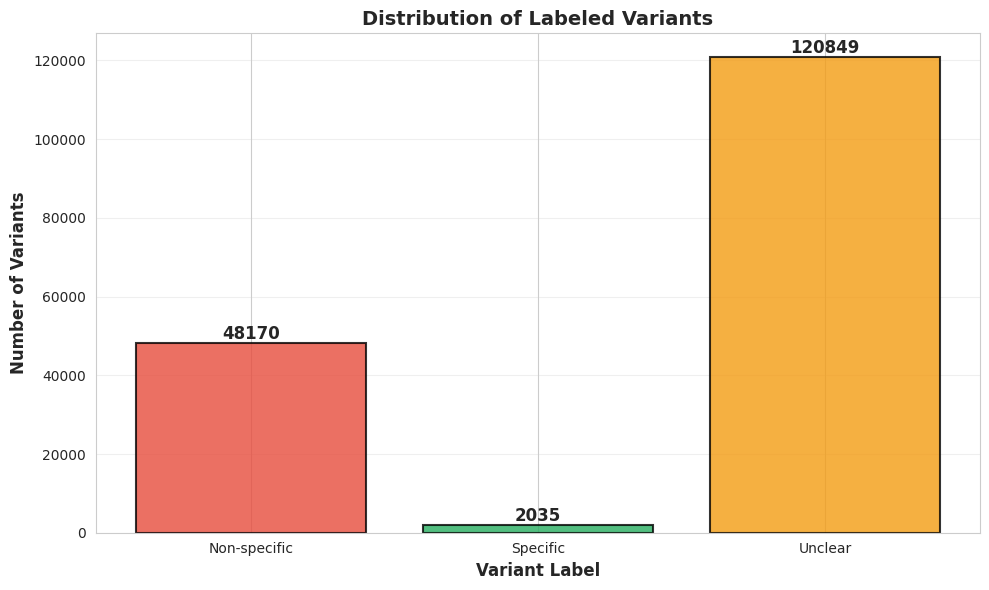

In [5]:
# Create bar plot for label distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Define labels and colors
label_names = {0: 'Non-specific', 1: 'Specific', 2: 'Unclear'}
colors = ['#e74c3c', '#27ae60', '#f39c12']

# Count labels
label_counts = df['label'].value_counts().sort_index()
labels = [label_names[i] for i in label_counts.index]
counts = label_counts.values

# Create bar plot
bars = ax.bar(labels, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize plot
ax.set_ylabel('Number of Variants', fontsize=12, fontweight='bold')
ax.set_xlabel('Variant Label', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Labeled Variants', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Enrichment columns found:
['enrich_pos3x_vs_neg', 'enrich_pos1x_vs_neg', 'enrich_pos3x_vs_lib', 'enrich_pos1x_vs_lib']
enrich_pos3x_vs_neg: min=1.064e-06, max=1.002e+07, median=0.003412
enrich_pos1x_vs_neg: min=1.064e-06, max=2.463e+06, median=0.003412
enrich_pos3x_vs_lib: min=2.193e-06, max=3.57e+05, median=0.00325
enrich_pos1x_vs_lib: min=2.135e-06, max=6.669e+04, median=0.00325


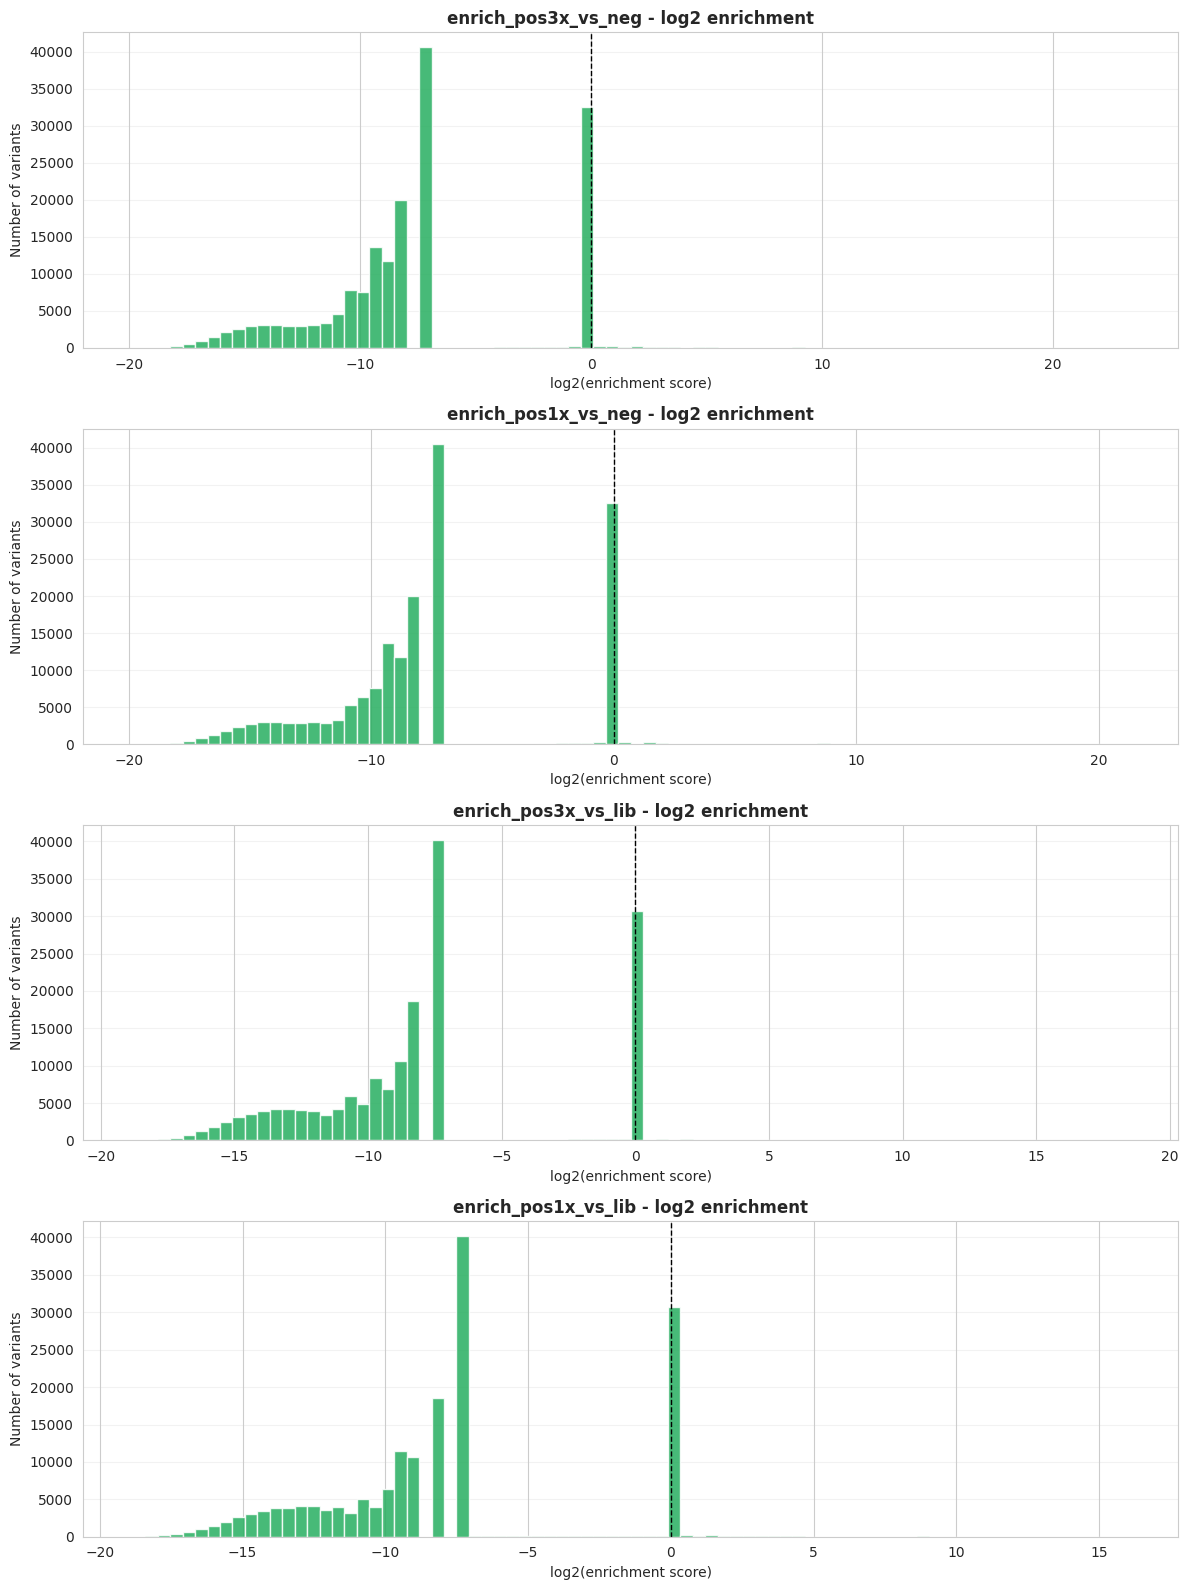

In [6]:
# Plot only the log2 distribution of enrichment score columns
# This automatically finds every column whose name starts with 'enrich'
enrich_cols = [col for col in df.columns if col.startswith('enrich')]

print('Enrichment columns found:')
print(enrich_cols)

if not enrich_cols:
    print('No enrichment columns found in the dataframe.')
else:
    n_cols = len(enrich_cols)
    fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4 * n_cols))

    if n_cols == 1:
        axes = np.array([axes])

    for i, col in enumerate(enrich_cols):
        raw_values = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        log2_values = np.log2(raw_values[raw_values > 0])

        ax = axes[i]
        ax.hist(log2_values, bins=80, color='#27ae60', alpha=0.85, edgecolor='white')
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{col} - log2 enrichment', fontweight='bold')
        ax.set_xlabel('log2(enrichment score)')
        ax.set_ylabel('Number of variants')
        ax.grid(axis='y', alpha=0.25)

        print(f"{col}: min={raw_values.min():.4g}, max={raw_values.max():.4g}, median={raw_values.median():.4g}")

    plt.tight_layout()
    plt.show()

## 3. Plot Frequency of Most Common Sequences
Generate four frequency distribution plots showing the 30 most frequent amino acid sequences
in each category:
- **Positive 3x**: Variants enriched in positive selection with high occurrence (3x)
- **Positive 1x**: Variants enriched in positive selection with lower occurrence (1x)
- **Negative**: Variants enriched in negative selection
- **Original Library**: All variants from the original library

Each plot displays amino acid sequences on the x-axis and their occurrence count on the y-axis.

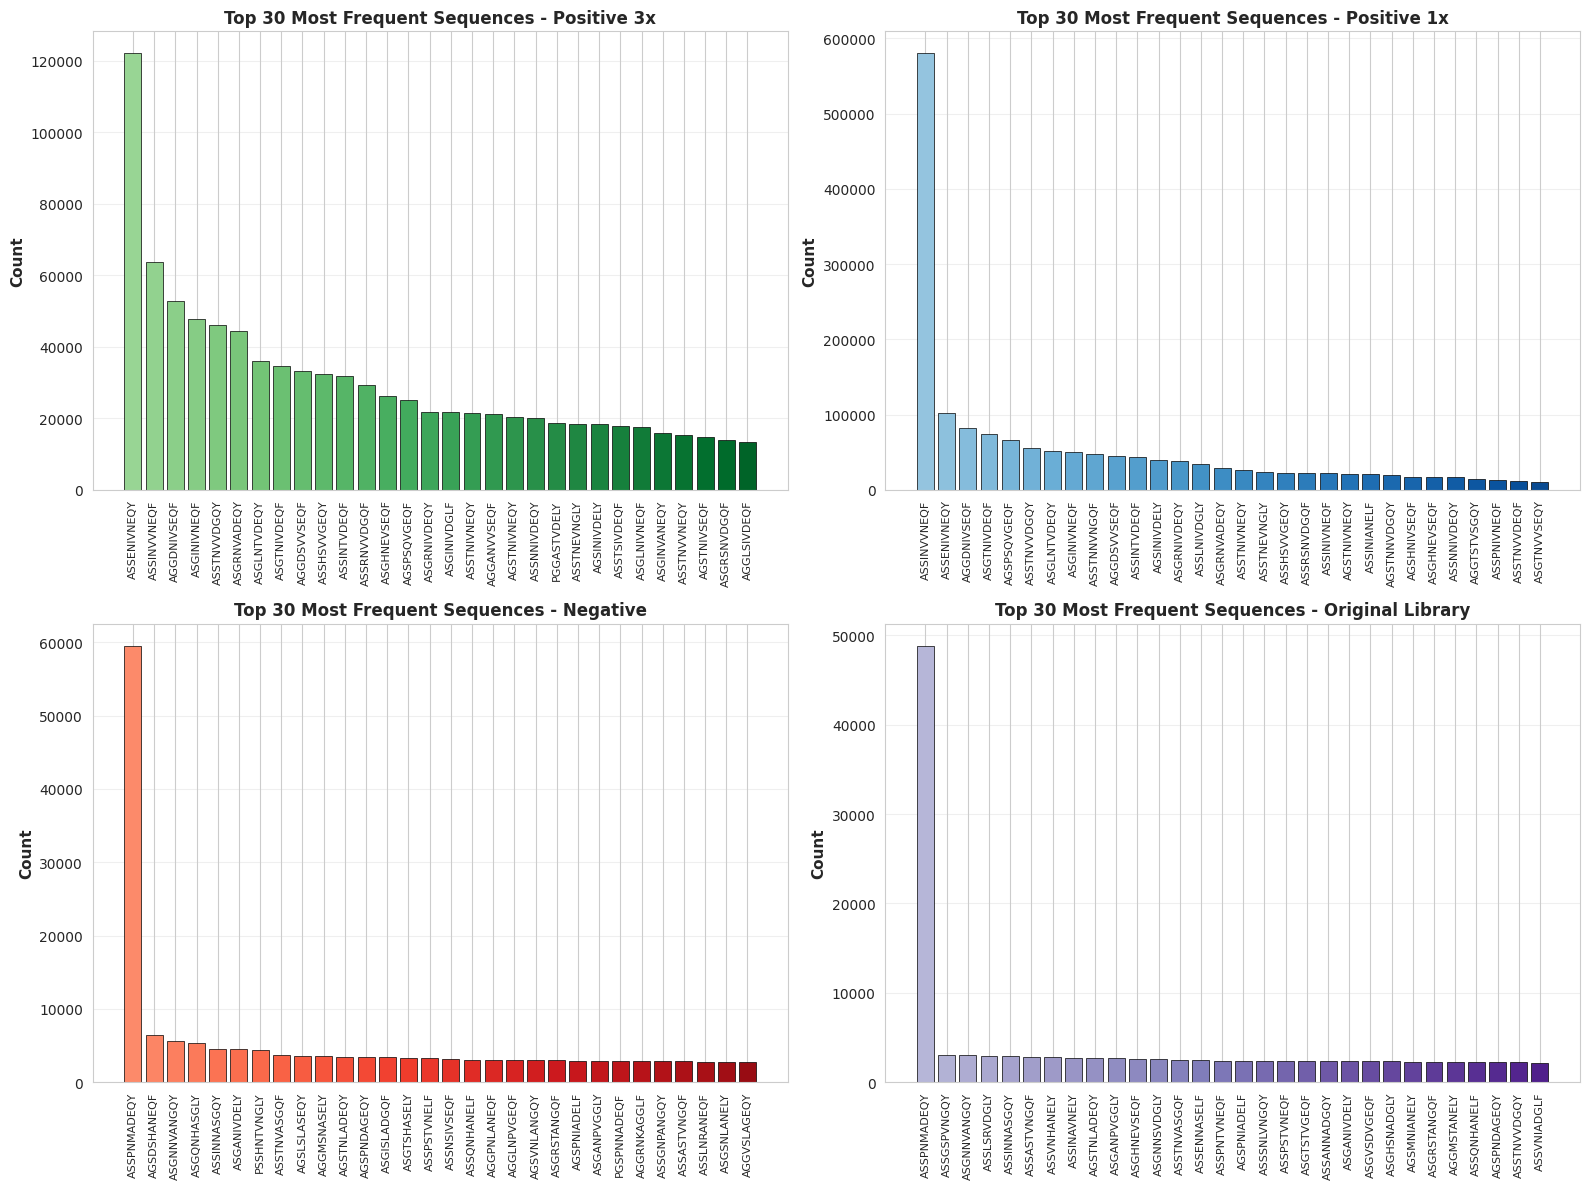


Frequency Summary:
Positive 3x - Top sequence: ASSENIVNEQY (count: 122168.0)
Positive 3x1x - Top sequence: ASSINVVNEQF (count: 580296.0)
Negative - Top sequence: ASSPNMADEQY (count: 59566.0)
Library - Top sequence: ASSPNMADEQY (count: 48862.0)


In [7]:
# Prepare data for frequency plots
# Filter sequences and their counts for each category

# Positive 3x: sequences with count_pos3x > 0
pos3x_data = df[df['count_pos3x'] > 0].sort_values('count_pos3x', ascending=False).head(30)

# Positive 1x: sequences with count_pos1x > 0 (excluding those with count_pos3x)
pos1x_data = df[df['count_pos1x'] > 0].sort_values('count_pos1x', ascending=False).head(30)

# Negative: sequences with count_neg > 0 (excluding positive categories)
neg_data = df[df['count_neg'] > 0].sort_values('count_neg', ascending=False).head(30)

# Library: all sequences by their library count
lib_data = df.sort_values('count_lib', ascending=False).head(30)

# Create a 2x2 subplot figure for all frequency plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Positive 3x
ax = axes[0, 0]
colors_pos3x = plt.cm.Greens(np.linspace(0.4, 0.9, len(pos3x_data)))
ax.bar(range(len(pos3x_data)), pos3x_data['count_pos3x'].values, color=colors_pos3x, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(pos3x_data)))
ax.set_xticklabels(pos3x_data['aa_seq'].values, rotation=90, fontsize=8)
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 30 Most Frequent Sequences - Positive 3x', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Positive 1x
ax = axes[0, 1]
colors_pos1x = plt.cm.Blues(np.linspace(0.4, 0.9, len(pos1x_data)))
ax.bar(range(len(pos1x_data)), pos1x_data['count_pos1x'].values, color=colors_pos1x, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(pos1x_data)))
ax.set_xticklabels(pos1x_data['aa_seq'].values, rotation=90, fontsize=8)
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 30 Most Frequent Sequences - Positive 1x', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 3: Negative
ax = axes[1, 0]
colors_neg = plt.cm.Reds(np.linspace(0.4, 0.9, len(neg_data)))
ax.bar(range(len(neg_data)), neg_data['count_neg'].values, color=colors_neg, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(neg_data)))
ax.set_xticklabels(neg_data['aa_seq'].values, rotation=90, fontsize=8)
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 30 Most Frequent Sequences - Negative', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Original Library
ax = axes[1, 1]
colors_lib = plt.cm.Purples(np.linspace(0.4, 0.9, len(lib_data)))
ax.bar(range(len(lib_data)), lib_data['count_lib'].values, color=colors_lib, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(lib_data)))
ax.set_xticklabels(lib_data['aa_seq'].values, rotation=90, fontsize=8)
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 30 Most Frequent Sequences - Original Library', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFrequency Summary:")
print(f"Positive 3x - Top sequence: {pos3x_data.iloc[0]['aa_seq']} (count: {pos3x_data.iloc[0]['count_pos3x']})")
print(f"Positive 3x1x - Top sequence: {pos1x_data.iloc[0]['aa_seq']} (count: {pos1x_data.iloc[0]['count_pos1x']})")
print(f"Negative - Top sequence: {neg_data.iloc[0]['aa_seq']} (count: {neg_data.iloc[0]['count_neg']})")
print(f"Library - Top sequence: {lib_data.iloc[0]['aa_seq']} (count: {lib_data.iloc[0]['count_lib']})")

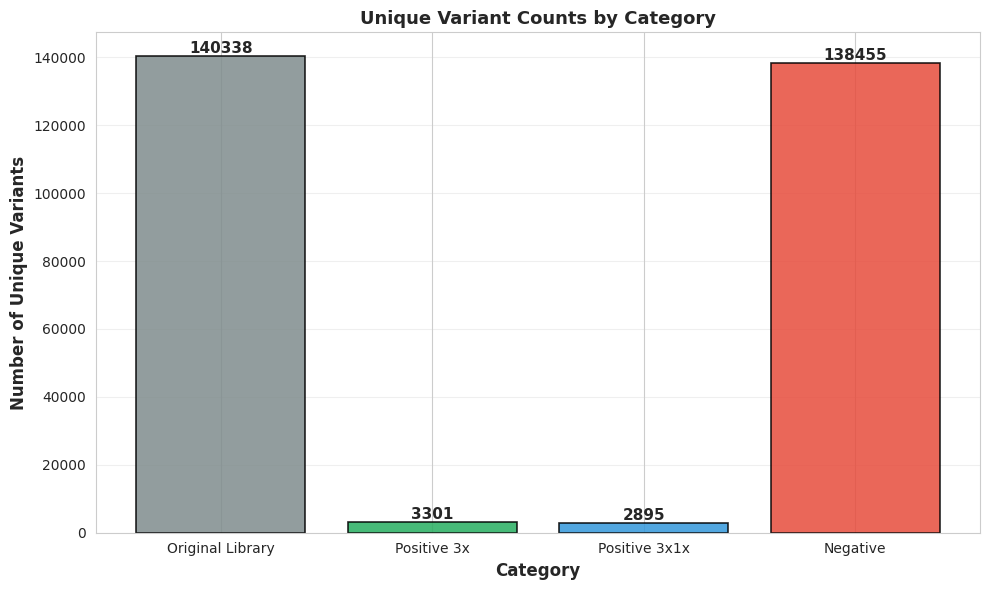


Unique variant counts:
                  n_unique_variants
Original Library             140338
Positive 3x                    3301
Positive 3x1x                  2895
Negative                     138455


In [8]:
# Plot number of unique variants in each category
# Using the same category definitions as above
n_pos3x = df[df['count_pos3x'] > 0]['aa_seq'].nunique()
n_pos1x = df[df['count_pos1x'] > 0]['aa_seq'].nunique()
n_neg = df[df['count_neg'] > 0]['aa_seq'].nunique()
n_library = df[df['count_lib'] > 0]['aa_seq'].nunique()

variant_counts = pd.Series({
    'Original Library': n_library,
    'Positive 3x': n_pos3x,
    'Positive 3x1x': n_pos1x,
    'Negative': n_neg
})

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#7f8c8d', '#27ae60', '#3498db', '#e74c3c']
bars = ax.bar(variant_counts.index, variant_counts.values, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Unique Variants', fontsize=12, fontweight='bold')
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_title('Unique Variant Counts by Category', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nUnique variant counts:")
print(variant_counts.to_frame('n_unique_variants'))

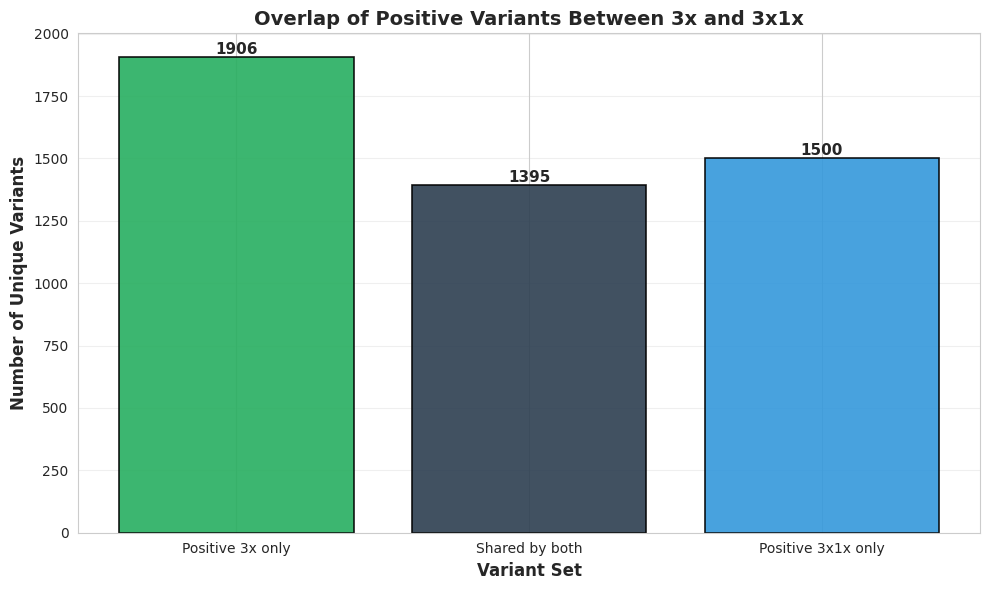

Overlap summary:
Positive 3x variants: 3301
Positive 3x1x variants: 2895
Shared variants: 1395
3x variants that are also in 3x1x: 1395 / 3301 (42.26%)
3x1x variants that are also in 3x: 1395 / 2895 (48.19%)

Example shared sequences (up to 20):
AGGANIVDEQF
AGGANIVDEQY
AGGANIVDGQY
AGGANIVNEQF
AGGANIVSEQF
AGGANIVSEQY
AGGANMVSEQF
AGGANRASGQY
AGGANVVNEQF
AGGANVVSEQF
AGGANVVSEQY
AGGASIVDEQY
AGGASIVNEQY
AGGASIVSEQF
AGGASTVDEQF
AGGASTVDEQY
AGGASTVNEQY
AGGDNIVDEQF
AGGDNIVDEQY
AGGDNIVGEQF


In [9]:
# Compare positive 3x and positive 3x1x variant sets
pos3x_variants = set(df.loc[df['count_pos3x'] > 0, 'aa_seq'])
pos1x_variants = set(df.loc[df['count_pos1x'] > 0, 'aa_seq'])
shared_variants = pos3x_variants & pos1x_variants
only_pos3x = pos3x_variants - pos1x_variants
only_pos1x = pos1x_variants - pos3x_variants

summary_counts = pd.Series({
    'Positive 3x only': len(only_pos3x),
    'Shared by both': len(shared_variants),
    'Positive 3x1x only': len(only_pos1x),
})

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60', '#2c3e50', '#3498db']
bars = ax.bar(summary_counts.index, summary_counts.values, color=colors, edgecolor='black', linewidth=1.2, alpha=0.9)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Number of Unique Variants', fontsize=12, fontweight='bold')
ax.set_xlabel('Variant Set', fontsize=12, fontweight='bold')
ax.set_title('Overlap of Positive Variants Between 3x and 3x1x', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Overlap summary:')
print(f"Positive 3x variants: {len(pos3x_variants)}")
print(f"Positive 3x1x variants: {len(pos1x_variants)}")
print(f"Shared variants: {len(shared_variants)}")
print(f"3x variants that are also in 3x1x: {len(shared_variants)} / {len(pos3x_variants)} ({len(shared_variants) / len(pos3x_variants) * 100:.2f}%)")
print(f"3x1x variants that are also in 3x: {len(shared_variants)} / {len(pos1x_variants)} ({len(shared_variants) / len(pos1x_variants) * 100:.2f}%)")

if shared_variants:
    print('\nExample shared sequences (up to 20):')
    for seq in sorted(list(shared_variants))[:20]:
        print(seq)


## 4. Plot Edit Distance from Wildtype
Calculate the Levenshtein distance (edit distance) between each variant sequence and a wildtype
reference sequence. This measures how many amino acids differ between each variant and the wildtype.
The distances range from 0 to 11, and the distribution is displayed as a bar plot.

In [ ]:
# Define the wildtype (reference) sequence
# This should be the most common sequence from the library
# If you have a specific wildtype sequence, replace this with your reference sequence

# Get the most common sequence from the library as wildtype reference
wildtype = df.loc[df['count_lib'].idxmax(), 'aa_seq']
print(f"Wildtype sequence (most frequent in library): {wildtype}")
print(f"Wildtype length: {len(wildtype)} amino acids")

# Calculate edit distance for all sequences
df['edit_distance'] = df['aa_seq'].apply(lambda seq: levenshtein_distance(seq, wildtype))

# Display basic statistics about edit distances
print(f"\nEdit Distance Statistics:")
print(f"Minimum distance: {df['edit_distance'].min()}")
print(f"Maximum distance: {df['edit_distance'].max()}")
print(f"Mean distance: {df['edit_distance'].mean():.2f}")
print(f"Median distance: {df['edit_distance'].median():.2f}")

In [ ]:
# Create edit distance distribution plot
fig, ax = plt.subplots(figsize=(12, 6))

# Count the number of variants at each edit distance
edit_distance_counts = df['edit_distance'].value_counts().sort_index()

# Create bar plot
colors_dist = plt.cm.viridis(np.linspace(0, 1, len(edit_distance_counts)))
bars = ax.bar(edit_distance_counts.index, edit_distance_counts.values, 
               color=colors_dist, alpha=0.8, edgecolor='black', linewidth=1)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('Edit Distance (Levenshtein Distance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Variants', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of Edit Distances from Wildtype\n(Wildtype: {wildtype})', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(int(df['edit_distance'].min()), int(df['edit_distance'].max()) + 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print distance distribution table
print("\nEdit Distance Distribution:")
print(edit_distance_counts.to_frame('Count'))
print(f"\nTotal variants analyzed: {len(df)}")